In [1]:
import pandas as pd

df = pd.read_csv("datasets/dataset_phishing.csv")

df.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [2]:
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={"status":"label"},inplace=True)

In [3]:
df['label'] = df['label'].map({
    "legitimate": 0,
    "phishing": 1
})

In [4]:
len(df)

11430

In [5]:
df['label'].value_counts()

label
0    5715
1    5715
Name: count, dtype: int64

In [7]:
def extract_url_features(url):
    url_lower = url.lower()

    return {
        # basic lexical features
        "url_length": len(url),
        "num_dots": url.count('.'),
        "num_hyphens": url.count('-'),
        "num_underscores": url.count('_'),
        "num_digits": sum(c.isdigit() for c in url),
        "num_slashes": url.count('/'),

        # security signals
        "has_https": int("https" in url),
        "has_http": int("http://" in url),
        "has_at": int("@" in url),
        "has_ip": int(any(part.isdigit() for part in url.split('/')[0].split('.'))),

        # phishing keyword signals
        "has_login": int("login" in url_lower),
        "has_secure": int("secure" in url_lower),
        "has_verify": int("verify" in url_lower),
        "has_update": int("update" in url_lower),
        "has_account": int("account" in url_lower),

        # structural signals
        "subdomain_count": url.count('.') - 1 if url.count('.') > 0 else 0,
        "tld_length": len(url.split('.')[-1]) if '.' in url else 0
    }

url_features = df['url'].apply(extract_url_features).apply(pd.Series)

X = url_features
y = df['label']

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler(with_mean=False)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42),
    "SVM": SVC(probability=True)
}

results = {}

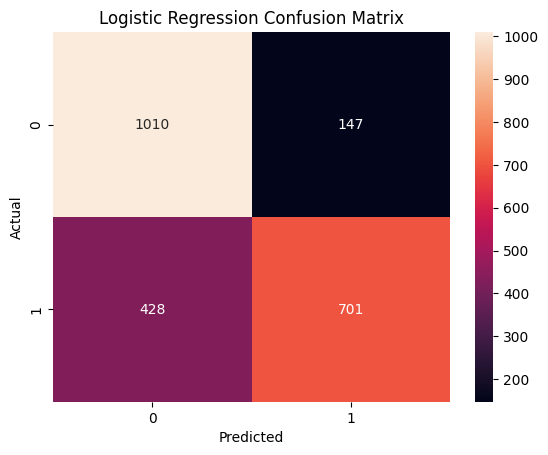

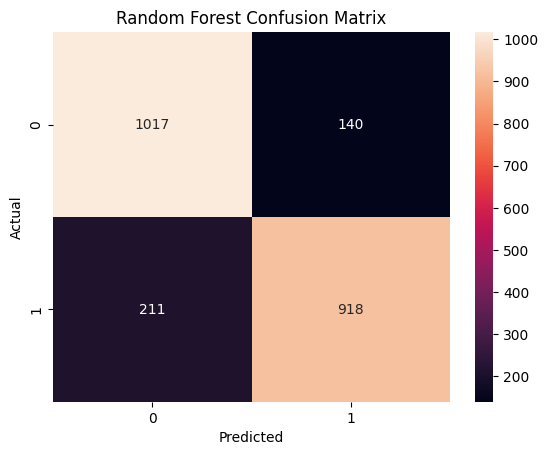

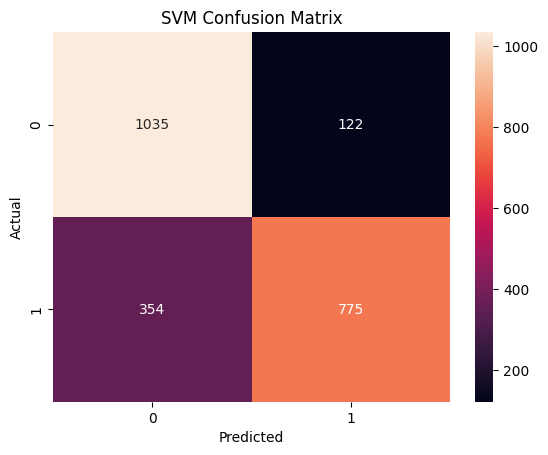

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for name, model in models.items():
    # ✅ TRAIN FIRST
    model.fit(X_train, y_train)

    # THEN predict
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [11]:
rf = models["Random Forest"]

importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp.head(10))

            Feature  Importance
0        url_length    0.238046
4        num_digits    0.164092
16       tld_length    0.163482
5       num_slashes    0.108927
2       num_hyphens    0.097197
1          num_dots    0.061764
15  subdomain_count    0.053627
3   num_underscores    0.030147
10        has_login    0.028676
7          has_http    0.013347


In [12]:
def predict_input(input_data):
    input_scaled = scaler.transform([input_data])
    
    prob = rf.predict_proba(input_scaled)[0][1]

    threshold = 0.4  # 🔥 tune this (0.3–0.5)

    pred = 1 if prob >= threshold else 0

    return {
        "prediction": "Phishing" if pred == 1 else "Legitimate",
        "risk_score": round(prob * 100, 2)
    }

In [13]:
import joblib

joblib.dump(rf, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']